In [11]:
import torch
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('=' * 60)
print('KIỂM TRA MÔI TRƯỜNG')
print('=' * 60)
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
    print('\n✅ GPU sẵn sàng! Training sẽ chạy ~15–20 phút cho 100 epochs.')
else:
    print('\n' + '!' * 60)
    print('❌ KHÔNG TÌM THẤY GPU!')
    print('   Training trên CPU sẽ mất ~10 TIẾNG — KHÔNG NÊN CHẠY!')
    print('   → Runtime → Change runtime type → T4 GPU → Save')
    print('   → Sau đó chạy lại từ Cell 1!')
    print('!' * 60)
    raise SystemExit('Dừng: Cần bật GPU T4 trước khi tiếp tục!')

drive.mount('/content/drive')
print('\n✅ Google Drive đã kết nối!')

Mounted at /content/drive
KIỂM TRA MÔI TRƯỜNG
PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU  : Tesla T4
VRAM : 14.6 GB

✅ GPU sẵn sàng! Training sẽ chạy ~15–20 phút cho 100 epochs.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Google Drive đã kết nối!


In [6]:
!pip install ultralytics opencv-python-headless -q

from ultralytics import YOLO
import cv2

print(f'✅ Ultralytics OK')
print(f'✅ OpenCV {cv2.__version__}')

✅ Ultralytics OK
✅ OpenCV 4.13.0


In [31]:
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/CCCD_Project'
# ════════════════════════════════════════════════════════════

SRC_IMAGES  = os.path.join(DRIVE_PROJECT_DIR, 'Data/images')
SRC_LABELS  = os.path.join(DRIVE_PROJECT_DIR, 'Data/labels')
YOLO_MODEL  = os.path.join(DRIVE_PROJECT_DIR, 'yolo11n.pt')

COLAB_WORK  = '/content/cccd_work'
DATASET_DIR = os.path.join(COLAB_WORK, 'dataset')
YAML_PATH   = os.path.join(COLAB_WORK, 'dataset.yaml')
DRAWN_DIR   = os.path.join(COLAB_WORK, 'drawn_images')
PROJECT     = os.path.join(COLAB_WORK, 'runs/train')
RUN_NAME    = 'cccd_yolo11'

os.makedirs(COLAB_WORK, exist_ok=True)

EPOCHS      = 100
IMG_SIZE    = 640
BATCH_SIZE  = 16
TRAIN_RATIO = 0.80
RANDOM_SEED = 42
PATIENCE    = 30   # Tăng từ 20 → 30: dataset nhỏ loss dao động nhiều
DEVICE      = 0    # GPU đã xác nhận ở Cell 1

CLASS_NAMES = [
    'card',         # 0 — Khung toàn bộ thẻ CCCD
    'dob',          # 1 — Ngày sinh
    'expiry',       # 2 — Ngày hết hạn
    'gender',       # 3 — Giới tính
    'id_number',    # 4 — Số CCCD
    'name',         # 5 — Họ và Tên
    'nationality',  # 6 — Quốc tịch
    'origin',       # 7 — Quê quán
    'residence',    # 8 — Nơi thường trú
]


print('=' * 60)
print('CẤU HÌNH DỰ ÁN')
print('=' * 60)
print(f'Drive project   : {DRIVE_PROJECT_DIR}')
print(f'Nguồn ảnh       : {SRC_IMAGES}')
print(f'Model pretrained: {YOLO_MODEL}')
print(f'Dataset (Colab) : {DATASET_DIR}')
print(f'Device          : GPU {DEVICE}')
print(f'Batch / Epochs  : {BATCH_SIZE} / {EPOCHS}  (patience={PATIENCE})')
print(f'\nDanh sách class ({len(CLASS_NAMES)} classes):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  [{i}] {name}')

# Fallback nếu không tìm thấy file .pt trên Drive
if not os.path.exists(YOLO_MODEL):
    print(f'\n⚠️  Không tìm thấy {YOLO_MODEL} — sẽ tự tải từ internet khi train.')
    YOLO_MODEL = 'yolo11n.pt'
else:
    print(f'\n✅ Model pretrained: {YOLO_MODEL}')

if os.path.exists(SRC_IMAGES):
    img_count = len([
        f for f in os.listdir(SRC_IMAGES)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ])
    print(f'✅ Tìm thấy {img_count} ảnh trong {SRC_IMAGES}')
else:
    raise FileNotFoundError(f'Không tìm thấy thư mục ảnh: {SRC_IMAGES}')

CẤU HÌNH DỰ ÁN
Drive project   : /content/drive/MyDrive/CCCD_Project
Nguồn ảnh       : /content/drive/MyDrive/CCCD_Project/Data/images
Model pretrained: /content/drive/MyDrive/CCCD_Project/yolo11n.pt
Dataset (Colab) : /content/cccd_work/dataset
Device          : GPU 0
Batch / Epochs  : 16 / 100  (patience=30)

Danh sách class (9 classes):
  [0] card
  [1] dob
  [2] expiry
  [3] gender
  [4] id_number
  [5] name
  [6] nationality
  [7] origin
  [8] residence

⚠️  Không tìm thấy /content/drive/MyDrive/CCCD_Project/yolo11n.pt — sẽ tự tải từ internet khi train.
✅ Tìm thấy 946 ảnh trong /content/drive/MyDrive/CCCD_Project/Data/images


In [32]:
import random
import os
import time

def prepare_dataset():
    print('=' * 60)
    print('CHUẨN BỊ DATASET')
    print('=' * 60)

    img_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    all_images = sorted([
        f for f in os.listdir(SRC_IMAGES)
        if f.lower().endswith(img_exts)
    ])
    print(f'Tổng số ảnh: {len(all_images)}')

    valid_images = [
        f for f in all_images
        if os.path.exists(os.path.join(SRC_LABELS, os.path.splitext(f)[0] + '.txt'))
    ]
    skipped = len(all_images) - len(valid_images)
    if skipped:
        print(f'  [!] Bỏ qua {skipped} ảnh không có label')
    print(f'Ảnh có label: {len(valid_images)}')

    random.seed(RANDOM_SEED)
    random.shuffle(valid_images)
    split_idx   = int(len(valid_images) * TRAIN_RATIO)
    train_files = valid_images[:split_idx]
    val_files   = valid_images[split_idx:]
    print(f'Train: {len(train_files)} | Val: {len(val_files)}')

    for subset in ('train', 'val'):
        os.makedirs(os.path.join(DATASET_DIR, 'images', subset), exist_ok=True)
        os.makedirs(os.path.join(DATASET_DIR, 'labels', subset), exist_ok=True)

    for subset, file_list in (('train', train_files), ('val', val_files)):
        t0      = time.time()
        dst_img = os.path.join(DATASET_DIR, 'images', subset)
        dst_lbl = os.path.join(DATASET_DIR, 'labels', subset)
        img_lst = f'/tmp/{subset}_images.txt'
        lbl_lst = f'/tmp/{subset}_labels.txt'

        with open(img_lst, 'w') as fi, open(lbl_lst, 'w') as fl:
            for img_name in file_list:
                base = os.path.splitext(img_name)[0]
                fi.write(os.path.join(SRC_IMAGES, img_name) + '\n')
                fl.write(os.path.join(SRC_LABELS, base + '.txt') + '\n')

        os.system(f'xargs -a {img_lst} cp -t {dst_img}')
        os.system(f'xargs -a {lbl_lst} cp -t {dst_lbl}')

        # Chuẩn hóa line endings Windows → Unix
        os.system(f"find {dst_lbl} -name '*.txt' -exec sed -i 's/\\r//' {{}} +")
        print(f'  [{subset}] ✅ Xong trong {time.time() - t0:.1f}s')

    # Tạo dataset.yaml
    yaml_lines = [
        '# Dataset CCCD Việt Nam — YOLOv11',
        f'path: {DATASET_DIR}',
        'train: images/train',
        'val:   images/val',
        '',
        f'nc: {len(CLASS_NAMES)}',
        '',
        'names:',
    ] + [f'  {i}: {name}' for i, name in enumerate(CLASS_NAMES)]

    yaml_content = '\n'.join(yaml_lines) + '\n'
    with open(YAML_PATH, 'w', encoding='utf-8') as f:
        f.write(yaml_content)

    print(f'\n✅ Đã tạo: {YAML_PATH}')
    print('\n--- dataset.yaml ---')
    print(yaml_content)

    n_ti = len(os.listdir(os.path.join(DATASET_DIR, 'images', 'train')))
    n_vi = len(os.listdir(os.path.join(DATASET_DIR, 'images', 'val')))
    print(f'Kiểm tra: train={n_ti} ảnh | val={n_vi} ảnh')


prepare_dataset()


CHUẨN BỊ DATASET
Tổng số ảnh: 946
Ảnh có label: 946
Train: 756 | Val: 190
  [train] ✅ Xong trong 324.4s
  [val] ✅ Xong trong 74.7s

✅ Đã tạo: /content/cccd_work/dataset.yaml

--- dataset.yaml ---
# Dataset CCCD Việt Nam — YOLOv11
path: /content/cccd_work/dataset
train: images/train
val:   images/val

nc: 9

names:
  0: card
  1: dob
  2: expiry
  3: gender
  4: id_number
  5: name
  6: nationality
  7: origin
  8: residence

Kiểm tra: train=756 ảnh | val=190 ảnh


TRỰC QUAN HÓA LABEL
Xử lý 20 ảnh...
  20/20 ảnh...

✅ Xong! 20 ảnh đã lưu, 20 ảnh có box.

📷 3 ảnh mẫu — kiểm tra nhãn có đúng vùng thông tin không:
  → cccd_0016.jpg


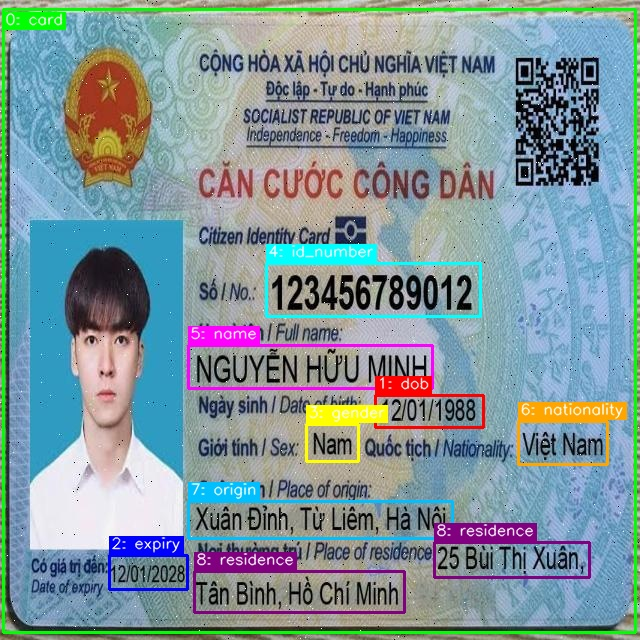

  → cccd_0009.jpg


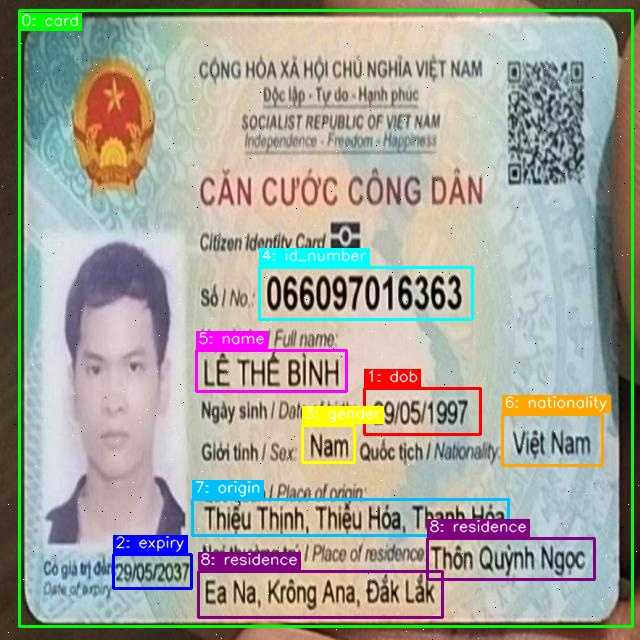

  → cccd_0017.jpg


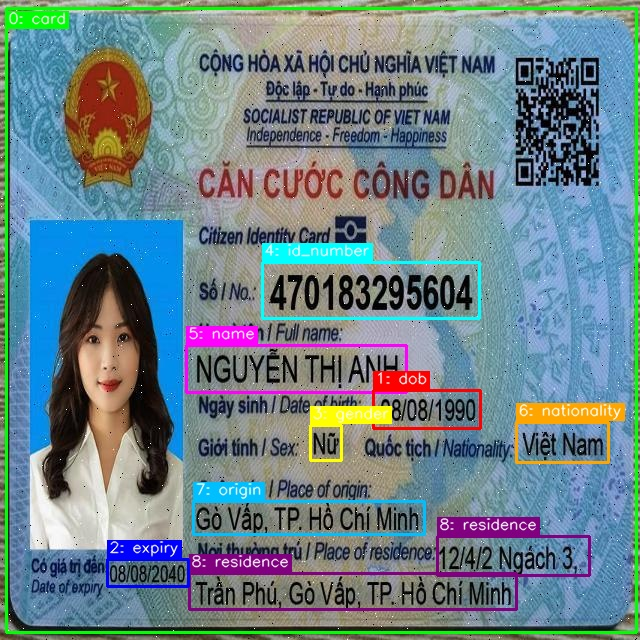

In [33]:
import os
import cv2
import glob
import random
from IPython.display import Image, display


def draw_bounding_boxes(images_dir, labels_dir, output_dir, class_names, max_draw=None):
    """
    Vẽ bounding box YOLO lên ảnh và lưu ra output_dir.

    Args:
        images_dir  : Thư mục ảnh gốc
        labels_dir  : Thư mục file label (.txt YOLO format)
        output_dir  : Thư mục lưu ảnh kết quả
        class_names : Danh sách tên class theo đúng thứ tự index
        max_draw    : Số ảnh tối đa cần xử lý (None = tất cả)
    """
    # Màu BGR — khớp đúng thứ tự CLASS_NAMES
    COLORS = [
        (0,   255,   0),   # 0 card
        (0,     0, 255),   # 1 dob
        (255,   0,   0),   # 2 expiry
        (0,   255, 255),   # 3 gender
        (255, 255,   0),   # 4 id_number
        (255,   0, 255),   # 5 name
        (0,   165, 255),   # 6 nationality
        (255, 191,   0),   # 7 origin
        (128,   0, 128),   # 8 residence
    ]

    os.makedirs(output_dir, exist_ok=True)
    img_exts   = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    img_files  = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(img_exts)])
    if max_draw is not None:
        img_files = img_files[:max_draw]

    print(f'Xử lý {len(img_files)} ảnh...')
    processed, drawn = 0, 0

    for idx, img_name in enumerate(img_files):
        img = cv2.imread(os.path.join(images_dir, img_name))
        if img is None:
            print(f'  [!] Không đọc được: {img_name}')
            continue

        h, w       = img.shape[:2]
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')
        boxes_drawn = 0

        if os.path.exists(label_path):
            with open(label_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                try:
                    cid         = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:5])
                except ValueError:
                    continue

                color = COLORS[cid % len(COLORS)]
                x1 = max(0,     int((xc - bw / 2) * w))
                y1 = max(0,     int((yc - bh / 2) * h))
                x2 = min(w - 1, int((xc + bw / 2) * w))
                y2 = min(h - 1, int((yc + bh / 2) * h))

                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

                lbl = f'{cid}: {class_names[cid]}' if cid < len(class_names) else str(cid)
                font = cv2.FONT_HERSHEY_SIMPLEX
                (tw, th), bl = cv2.getTextSize(lbl, font, 0.5, 1)
                ty = y1 - 5 if y1 - 5 - th > 0 else y1 + th + 5
                cv2.rectangle(img, (x1, ty - th - 2), (x1 + tw + 4, ty + bl - 2), color, cv2.FILLED)
                cv2.putText(img, lbl, (x1 + 2, ty - 2), font, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
                boxes_drawn += 1
        else:
            print(f'  [!] Không có label: {img_name}')

        cv2.imwrite(os.path.join(output_dir, img_name), img)
        processed += 1
        if boxes_drawn > 0:
            drawn += 1
        if (idx + 1) % 50 == 0 or (idx + 1) == len(img_files):
            print(f'  {idx + 1}/{len(img_files)} ảnh...')

    print(f'\n✅ Xong! {processed} ảnh đã lưu, {drawn} ảnh có box.')

    print('=' * 60)
print('TRỰC QUAN HÓA LABEL')
print('=' * 60)

draw_bounding_boxes(SRC_IMAGES, SRC_LABELS, DRAWN_DIR, class_names=CLASS_NAMES, max_draw=20)

drawn_files = (
    glob.glob(os.path.join(DRAWN_DIR, '*.jpg')) +
    glob.glob(os.path.join(DRAWN_DIR, '*.png'))
)
if drawn_files:
    print('\n📷 3 ảnh mẫu — kiểm tra nhãn có đúng vùng thông tin không:')
    for p in random.sample(drawn_files, min(3, len(drawn_files))):
        print(f'  → {os.path.basename(p)}')
        display(Image(filename=p, width=600))
else:
    print('Không tìm thấy ảnh nào trong DRAWN_DIR.')

In [34]:
import os
import shutil
import torch
from datetime import datetime
from ultralytics import YOLO

if not torch.cuda.is_available():
    raise RuntimeError('Không có GPU! Vào Runtime → Change runtime type → T4 GPU → Save, rồi chạy lại từ Cell 1.')
print(f'✅ GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB VRAM)')

print('\n' + '=' * 60)
print('TRAINING YOLOv11')
print('=' * 60)
print(f'Model   : {YOLO_MODEL}')
print(f'Epochs  : {EPOCHS}  |  Patience: {PATIENCE}')
print(f'Batch   : {BATCH_SIZE}  |  Img size: {IMG_SIZE}')

if not os.path.exists(YAML_PATH):
    raise FileNotFoundError(f'Không tìm thấy {YAML_PATH} — chạy Cell 4 trước!')

model   = YOLO(YOLO_MODEL)
results = model.train(
    data        = YAML_PATH,
    epochs      = EPOCHS,
    imgsz       = IMG_SIZE,
    batch       = BATCH_SIZE,
    device      = DEVICE,
    project     = PROJECT,
    name        = RUN_NAME,
    patience    = PATIENCE,
    # ── Lưu & đánh giá ──────────────────────────────────────
    save        = True,
    save_period = 10,
    val         = True,
    plots       = True,
    # ── Tốc độ ──────────────────────────────────────────────
    amp         = True,    # Mixed precision — nhanh hơn ~30% trên GPU
    cache       = True,    # Cache ảnh vào RAM — tránh đọc ổ cứng lặp lại
    workers     = 2,
    # ── Augmentation (phù hợp cho ảnh tài liệu CCCD) ────────
    hsv_h       = 0.015,   # Thay đổi màu nhẹ (ánh sáng khác nhau)
    hsv_s       = 0.4,
    hsv_v       = 0.4,
    degrees     = 2.0,     # Giảm từ 5 → 2: CCCD ít khi nghiêng nhiều
    translate   = 0.1,
    scale       = 0.2,     # Giảm từ 0.3 → 0.2
    flipud      = 0.0,     # Tắt: CCCD không bao giờ lật ngược
    fliplr      = 0.0,     # Tắt: chữ sẽ bị ngược nếu lật
    mosaic      = 0.3,     # Giảm từ 0.5 → 0.3
    mixup       = 0.0,     # Tắt
)

best_pt = os.path.join(PROJECT, RUN_NAME, 'weights', 'best.pt')
print(f'\n✅ Training hoàn thành! Model tốt nhất: {best_pt}')

# ── Tự động lưu kết quả về Drive ─────────────────────────────
print('\n📦 Đang lưu kết quả về Google Drive...')
timestamp    = datetime.now().strftime('%Y%m%d_%H%M%S')
drive_run    = os.path.join(DRIVE_PROJECT_DIR, f'runs/train_{timestamp}')
os.makedirs(drive_run, exist_ok=True)
shutil.copytree(os.path.join(PROJECT, RUN_NAME), os.path.join(drive_run, RUN_NAME), dirs_exist_ok=True)
if os.path.exists(best_pt):
    shutil.copy2(best_pt, os.path.join(DRIVE_PROJECT_DIR, 'best.pt'))
print(f'✅ best.pt → {DRIVE_PROJECT_DIR}/best.pt')
print(f'✅ Toàn bộ kết quả → {drive_run}')

✅ GPU: Tesla T4 (14.6 GB VRAM)

TRAINING YOLOv11
Model   : yolo11n.pt
Epochs  : 100  |  Patience: 30
Batch   : 16  |  Img size: 640
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cccd_work/dataset.yaml, degrees=2.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosai

In [35]:
from IPython.display import Image, display
import glob
import os

run_dir = os.path.join(PROJECT, RUN_NAME)
print(f'Thư mục kết quả: {run_dir}')

for title, path, w in [
    ('📈 Đồ thị loss & metrics', os.path.join(run_dir, 'results.png'),          900),
    ('🔢 Confusion Matrix',      os.path.join(run_dir, 'confusion_matrix.png'), 700),
]:
    if os.path.exists(path):
        print(f'\n{title}:')
        display(Image(filename=path, width=w))

val_samples = glob.glob(os.path.join(run_dir, 'val_batch*_pred.jpg'))
if val_samples:
    print('\n🖼️ Ảnh validation — ground truth vs prediction:')
    for p in val_samples[:2]:
        display(Image(filename=p, width=900))

Output hidden; open in https://colab.research.google.com to view.

In [36]:
from ultralytics import YOLO
import os

best_pt = os.path.join(PROJECT, RUN_NAME, 'weights', 'best.pt')
if not os.path.exists(best_pt):
    raise FileNotFoundError('Không tìm thấy model — chạy Cell 6 trước!')

print('=' * 60)
print('ĐÁNH GIÁ MODEL')
print('=' * 60)

model   = YOLO(best_pt)
metrics = model.val(data=YAML_PATH, device=DEVICE)

print(f'\n{"─" * 40}')
print('KẾT QUẢ TỔNG QUAN')
print(f'{"─" * 40}')
print(f'Precision  : {metrics.box.mp:.4f}')
print(f'Recall     : {metrics.box.mr:.4f}')
print(f'mAP@50     : {metrics.box.map50:.4f}')
print(f'mAP@50:95  : {metrics.box.map:.4f}')

print(f'\n{"─" * 40}')
print('mAP@50 THEO TỪNG CLASS')
print(f'{"─" * 40}')
for i, (name, ap50) in enumerate(zip(CLASS_NAMES, metrics.box.ap50)):
    bar = '█' * int(ap50 * 20)
    print(f'  [{i}] {name:<12} : {ap50:.4f}  {bar}')

ĐÁNH GIÁ MODEL
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,907 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1844.7±665.9 MB/s, size: 271.5 KB)
val: Scanning /content/cccd_work/dataset/labels/val.cache... 190 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 190/190 66.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.5it/s 4.7s
                   all        190       1900      0.994      0.993      0.992      0.713
                  card        189        191      0.993       0.99      0.989      0.976
                   dob        189        192      0.993      0.984      0.984      0.683
                expiry        190        191      0.994       0.99      0.991      0.663
                gender        190        191          1      0.993      0.995      0.517
             id_number